# Monte Carlo flight viewer

Load the pickle generated by `montecarlorunner.py`, reduce each complete RocketPy state history to flight-level metrics with NumPy, and analyze the results with pandas. The plots show distributions of peak altitude, ignition attitude angle from vertical, and maximum 3D velocity.

> Only open pickle files you trust. Python pickle files can execute code while loading.

In [174]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Select the Monte Carlo file

Change `PKL_PATH` if the runner output has a different name. `HISTOGRAM_BINS` accepts an integer or any NumPy histogram strategy such as `"auto"`, `"fd"`, or `"sturges"`. Set `EXCLUDE_TILT_LOCKOUTS_FROM_GRAPHS` to `True` to omit recorded tilt-lockout flights. Set `POSTPROCESS_TILT_LOCKOUT_MAX_ANGLE_DEG` to a number from 0 through 90 to try another lockout threshold against the saved ignition angles without rerunning the simulations; use `None` to disable that additional filter. Both filters apply to every graph, statistical envelope, and KML export.

In [175]:
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "montecarlorunner.py").is_file():
    PROJECT_DIR = PROJECT_DIR / "rocketpy"

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

PKL_PATH = PROJECT_DIR / "monte_carlo_flights.pkl"
if not PKL_PATH.is_file():
    PKL_PATH = PROJECT_DIR / "flight_data.pkl"

HISTOGRAM_BINS = 20  # Increase for finer frequency-curve resolution
EXCLUDE_TILT_LOCKOUTS_FROM_GRAPHS = True
POSTPROCESS_TILT_LOCKOUT_MAX_ANGLE_DEG = None  # Example: 20.0
REPORT_OUTPUT_PATH = PROJECT_DIR / "monte_carlo_report.pdf"
REPORT_PNG_OUTPUT_PATH = PROJECT_DIR / "monte_carlo_report.png"
REPORT_PNG_DPI = 300
REPORT_FIGURES = []
FLIGHT_PROFILE_PERCENTILE = 80.0
FLIGHT_PROFILE_TIME_STEP_S = 0.1
AVERAGE_FLIGHT_PROFILE_PATH = PROJECT_DIR / f"average_flight_profile_{FLIGHT_PROFILE_PERCENTILE:g}th_percentile.csv"
print(f"Loading: {PKL_PATH}")

Loading: C:\Users\E\Documents\GitHub\farfromheaven\sims\rocketpy\monte_carlo_flights.pkl


## Load and validate the results

In [176]:
from montecarlorunner import load_monte_carlo_output

monte_carlo = load_monte_carlo_output(PKL_PATH)

if not isinstance(monte_carlo, dict):
    raise TypeError("Expected the dictionary format written by montecarlorunner.py")
if monte_carlo.get("format") != "projectblaze.rocketpy.monte_carlo":
    raise ValueError(f"Unsupported Monte Carlo format: {monte_carlo.get('format')!r}")

flights = monte_carlo.get("flights", [])
state_columns = tuple(monte_carlo.get("state_columns", ()))
required_columns = {"time", "x", "y", "z", "vx", "vy", "vz", "e0", "e1", "e2", "e3"}
missing_columns = required_columns.difference(state_columns)
if not flights:
    raise ValueError("The pickle contains no flight records")
if missing_columns:
    raise ValueError(f"Flight state data is missing columns: {sorted(missing_columns)}")

tilt_lockout_count = sum(bool(flight.get("tilt_lockout_triggered", False)) for flight in flights)
print(f"Loaded {len(flights):,} flight records")
print(f"Recorded tilt lockouts: {tilt_lockout_count:,}")
print(f"Created: {monte_carlo.get('created_at_utc', 'unknown')}")

Loaded 10 flight records
Recorded tilt lockouts: 0
Created: 2026-08-30T01:30:06.883546+00:00


## Vectorized flight processing

Altitude is reported as peak height above the launch-site elevation. Ignition values use the state nearest the recorded sustainer ignition time. Maximum velocity is the largest magnitude of `(vx, vy, vz)`. Because the streamed output does not retain the atmospheric and wind profiles, Mach number and dynamic pressure are offline estimates based on the 1976 standard atmosphere and ground-relative velocity.

In [177]:
column = {name: index for index, name in enumerate(state_columns)}
launch_elevation_m = float(monte_carlo.get("environment", {}).get("elevation") or 0.0)

def quaternion_angle_from_vertical(quaternion):
    quaternion = np.asarray(quaternion, dtype=float)
    norm = np.linalg.norm(quaternion)
    if not np.isfinite(norm) or norm == 0:
        return np.nan
    e0, e1, e2, e3 = quaternion / norm
    vertical_component = e0**2 - e1**2 - e2**2 + e3**2
    return np.degrees(np.arccos(np.clip(vertical_component, -1.0, 1.0)))

def standard_atmosphere_density_and_sound_speed(altitude_m):
    """Return 1976-standard-atmosphere density and sound speed."""
    altitude_m = np.asarray(altitude_m, dtype=float)
    geopotential_height = np.maximum(altitude_m, -500.0) * 6_356_766.0 / (6_356_766.0 + np.maximum(altitude_m, -500.0))
    boundaries = np.array([0.0, 11_000.0, 20_000.0, 32_000.0, 47_000.0, 51_000.0, 71_000.0, 84_852.0])
    lapse_rates = np.array([-0.0065, 0.0, 0.001, 0.0028, 0.0, -0.0028, -0.002])
    gravity = 9.80665
    gas_constant = 287.05287
    gamma = 1.4
    base_temperature = [288.15]
    base_pressure = [101_325.0]
    for base_height, top_height, lapse_rate in zip(boundaries[:-1], boundaries[1:], lapse_rates):
        temperature = base_temperature[-1]
        pressure = base_pressure[-1]
        height_delta = top_height - base_height
        top_temperature = temperature + lapse_rate * height_delta
        top_pressure = (
            pressure * np.exp(-gravity * height_delta / (gas_constant * temperature))
            if lapse_rate == 0
            else pressure * (top_temperature / temperature) ** (-gravity / (lapse_rate * gas_constant))
        )
        base_temperature.append(top_temperature)
        base_pressure.append(top_pressure)

    temperature = np.empty_like(geopotential_height)
    pressure = np.empty_like(geopotential_height)
    layer_indices = np.searchsorted(boundaries[1:], geopotential_height, side="right")
    for layer_index in range(len(lapse_rates)):
        mask = layer_indices == layer_index
        height_delta = geopotential_height[mask] - boundaries[layer_index]
        layer_temperature = base_temperature[layer_index]
        lapse_rate = lapse_rates[layer_index]
        temperature[mask] = layer_temperature + lapse_rate * height_delta
        pressure[mask] = (
            base_pressure[layer_index] * np.exp(-gravity * height_delta / (gas_constant * layer_temperature))
            if lapse_rate == 0
            else base_pressure[layer_index] * (temperature[mask] / layer_temperature) ** (-gravity / (lapse_rate * gas_constant))
        )

    above_model = layer_indices == len(lapse_rates)
    height_delta = geopotential_height[above_model] - boundaries[-1]
    temperature[above_model] = base_temperature[-1]
    pressure[above_model] = base_pressure[-1] * np.exp(-gravity * height_delta / (gas_constant * base_temperature[-1]))
    density = pressure / (gas_constant * temperature)
    sound_speed = np.sqrt(gamma * gas_constant * temperature)
    return density, sound_speed

metric_records = []
velocity_columns = [column["vx"], column["vy"], column["vz"]]
quaternion_columns = [column["e0"], column["e1"], column["e2"], column["e3"]]

for record_index, flight in enumerate(flights):
    states = np.asarray(flight.get("solution", ()), dtype=float)
    if states.ndim != 2 or states.shape[0] == 0 or states.shape[1] < len(state_columns):
        raise ValueError(f"Flight record {record_index} has an invalid solution array")

    altitude = states[:, column["z"]]
    speed = np.linalg.norm(states[:, velocity_columns], axis=1)
    apogee_index = int(np.nanargmax(altitude))
    ignition_time = float(flight.get("ignition_time_s", states[0, column["time"]]))
    ignition_index = int(np.nanargmin(np.abs(states[:, column["time"]] - ignition_time)))
    ignition_quaternion = states[ignition_index, quaternion_columns]
    density, sound_speed = standard_atmosphere_density_and_sound_speed(altitude)
    estimated_mach = np.divide(speed, sound_speed, out=np.full_like(speed, np.nan), where=sound_speed > 0)
    estimated_dynamic_pressure = 0.5 * density * speed**2
    apogee_horizontal_distance_m = float(np.hypot(
        states[apogee_index, column["x"]], states[apogee_index, column["y"]]
    ))
    events = flight.get("events", {})
    impact_x = events.get("x_impact")
    impact_y = events.get("y_impact")
    if impact_x is not None and impact_y is not None:
        landing_distance_m = float(np.hypot(float(impact_x), float(impact_y)))
    elif states[-1, column["z"]] <= launch_elevation_m + 1.0:
        landing_distance_m = float(np.hypot(
            states[-1, column["x"]], states[-1, column["y"]]
        ))
    else:
        landing_distance_m = np.nan
    simulation_parameters = flight.get("simulation_parameters", {})

    metric_records.append({
        "record_index": record_index,
        "simulation_index": flight.get("simulation_index", record_index),
        "rocket_index": flight.get("rocket_index", 0),
        "rocket_name": flight.get("rocket_name") or f"rocket_{flight.get('rocket_index', 0)}",
        "tilt_lockout_triggered": bool(flight.get("tilt_lockout_triggered", False)),
        "launch_inclination_deg": float(flight.get("launch_angle", np.nan)),
        "launch_heading_deg": float(flight.get("heading", simulation_parameters.get("heading", np.nan))),
        "ignition_angle_deg_from_vertical": float(flight.get("ignition_angle_deg_from_vertical", quaternion_angle_from_vertical(ignition_quaternion))),
        "ignition_time_s": ignition_time,
        "ignition_velocity_m_s": float(speed[ignition_index]),
        "ignition_velocity_ft_s": float(speed[ignition_index] * 3.28084),
        "apogee_time_s": float(states[apogee_index, column["time"]]),
        "peak_altitude_m_agl": float(altitude[apogee_index] - launch_elevation_m),
        "peak_altitude_ft_agl": float((altitude[apogee_index] - launch_elevation_m) * 3.28084),
        "apogee_horizontal_distance_m": apogee_horizontal_distance_m,
        "apogee_horizontal_distance_ft": apogee_horizontal_distance_m * 3.28084,
        "landing_distance_m": landing_distance_m,
        "landing_distance_ft": landing_distance_m * 3.28084,
        "max_velocity_m_s": float(np.nanmax(speed)),
        "max_velocity_ft_s": float(np.nanmax(speed) * 3.28084),
        "max_mach_estimated": float(np.nanmax(estimated_mach)),
        "max_dynamic_pressure_pa_estimated": float(np.nanmax(estimated_dynamic_pressure)),
        "max_dynamic_pressure_psi_estimated": float(np.nanmax(estimated_dynamic_pressure) * 0.0001450377377),
    })

flight_metrics = pd.DataFrame.from_records(metric_records)
if POSTPROCESS_TILT_LOCKOUT_MAX_ANGLE_DEG is not None:
    POSTPROCESS_TILT_LOCKOUT_MAX_ANGLE_DEG = float(POSTPROCESS_TILT_LOCKOUT_MAX_ANGLE_DEG)
    if not np.isfinite(POSTPROCESS_TILT_LOCKOUT_MAX_ANGLE_DEG) or not 0 <= POSTPROCESS_TILT_LOCKOUT_MAX_ANGLE_DEG <= 90:
        raise ValueError("POSTPROCESS_TILT_LOCKOUT_MAX_ANGLE_DEG must be None or in [0, 90]")

excluded_by_tilt = np.zeros(len(flight_metrics), dtype=bool)
if EXCLUDE_TILT_LOCKOUTS_FROM_GRAPHS:
    excluded_by_tilt |= flight_metrics["tilt_lockout_triggered"].to_numpy(dtype=bool)
if POSTPROCESS_TILT_LOCKOUT_MAX_ANGLE_DEG is not None:
    excluded_by_tilt |= (
        flight_metrics["ignition_angle_deg_from_vertical"].to_numpy(dtype=float)
        > POSTPROCESS_TILT_LOCKOUT_MAX_ANGLE_DEG
    )

plot_flight_metrics = flight_metrics.loc[~excluded_by_tilt].copy()
if plot_flight_metrics.empty:
    raise ValueError("No flights remain after tilt-lockout filtering")
plot_record_indices = set(plot_flight_metrics["record_index"].astype(int))
plot_flights = [flight for index, flight in enumerate(flights) if index in plot_record_indices]
print(
    f"Tilt filter excluded {excluded_by_tilt.sum():,} flights; "
    f"{len(plot_flights):,} flights remain for graphs and KML export."
)
plot_flight_metrics.head()

Tilt filter excluded 0 flights; 10 flights remain for graphs and KML export.


,record_index,simulation_index,rocket_index,rocket_name,tilt_lockout_triggered,launch_inclination_deg,launch_heading_deg,ignition_angle_deg_from_vertical,ignition_time_s,ignition_velocity_m_s,...,peak_altitude_ft_agl,apogee_horizontal_distance_m,apogee_horizontal_distance_ft,landing_distance_m,landing_distance_ft,max_velocity_m_s,max_velocity_ft_s,max_mach_estimated,max_dynamic_pressure_pa_estimated,max_dynamic_pressure_psi_estimated
0,0,0,0,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,False,89.855910,358.877352,3.101347,13.207368,434.200612,...,393200.706222,9914.741116,32528.679243,19744.466220,64778.434554,1922.271851,6306.666380,6.514641,592916.407798,85.995254
1,1,1,0,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,False,89.732663,350.947437,0.777225,13.661770,446.880750,...,410998.977153,3059.154605,10036.596795,6038.311268,19810.733140,1927.365842,6323.378950,6.531905,562509.390660,81.585089
2,2,2,0,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,False,89.261678,207.360774,1.884617,13.922684,442.375718,...,439085.999434,6214.766938,20389.655960,12513.491541,41054.763587,1963.029724,6440.386438,6.652771,559781.939867,81.189506
3,3,3,0,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,False,88.546455,333.790083,2.573368,14.410725,432.067583,...,433373.621046,10961.922497,35964.313805,21732.407716,71300.552532,1944.160590,6378.479829,6.588823,537135.805857,77.904962
4,4,4,0,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,False,88.886778,132.285124,3.517758,10.400959,486.789544,...,274986.395158,9127.391949,29945.512601,18018.965442,59117.342582,1816.987853,5961.246428,6.097117,677774.770589,98.302919


## Summary statistics

In [178]:
summary_columns = [
    "peak_altitude_ft_agl",
    "ignition_angle_deg_from_vertical",
    "max_velocity_ft_s",
    "ignition_velocity_ft_s",
    "max_mach_estimated",
    "max_dynamic_pressure_psi_estimated",
]
summary = (
    plot_flight_metrics.groupby("rocket_name", sort=False)[summary_columns]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(2)
)
summary

peak_altitude_ft_agl  \
                                                                  count   
rocket_name                                                               
AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - S...                   10   

                                                                       \
                                                        mean      std   
rocket_name                                                             
AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - S...  409603.1  56679.5   

                                                                         \
                                                         min     median   
rocket_name                                                               
AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - S...  274986.4  418765.34   

                                                               \
                                                          max   
rocket_name                                                     
AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - S...  472974.07   

                                                   ignition_angle_deg_from_vertical  \
                                                                              count   
rocket_name                                                                           
AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - S...                               10   

                                                                      ...  \
                                                    mean   std   min  ...   
rocket_name                                                           ...   
AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - S...  1.86  1.02  0.32  ...   

                                                   max_mach_estimated       \
                                                                  std  min   
rocket_name                                                                  
AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - S...               0.18  6.1   

                                                                 \
                                                   median   max   
rocket_name                                                       
AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - S...   6.62  6.76   

                                                   max_dynamic_pressure_psi_estimated  \
                                                                                count   
rocket_name                                                                             
AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - S...                                 10   

                                                                               \
                                                     mean   std    min median   
rocket_name                                                                     
AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - S...  85.46  8.14  74.62  83.79   

                                                          
                                                     max  
rocket_name                                               
AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - S...  98.3  

[1 rows x 36 columns]

## Frequency distributions

Each rocket is plotted separately using shared bin edges so overlaid distributions remain comparable. The Matplotlib widget toolbar supports pan, zoom, and image export.

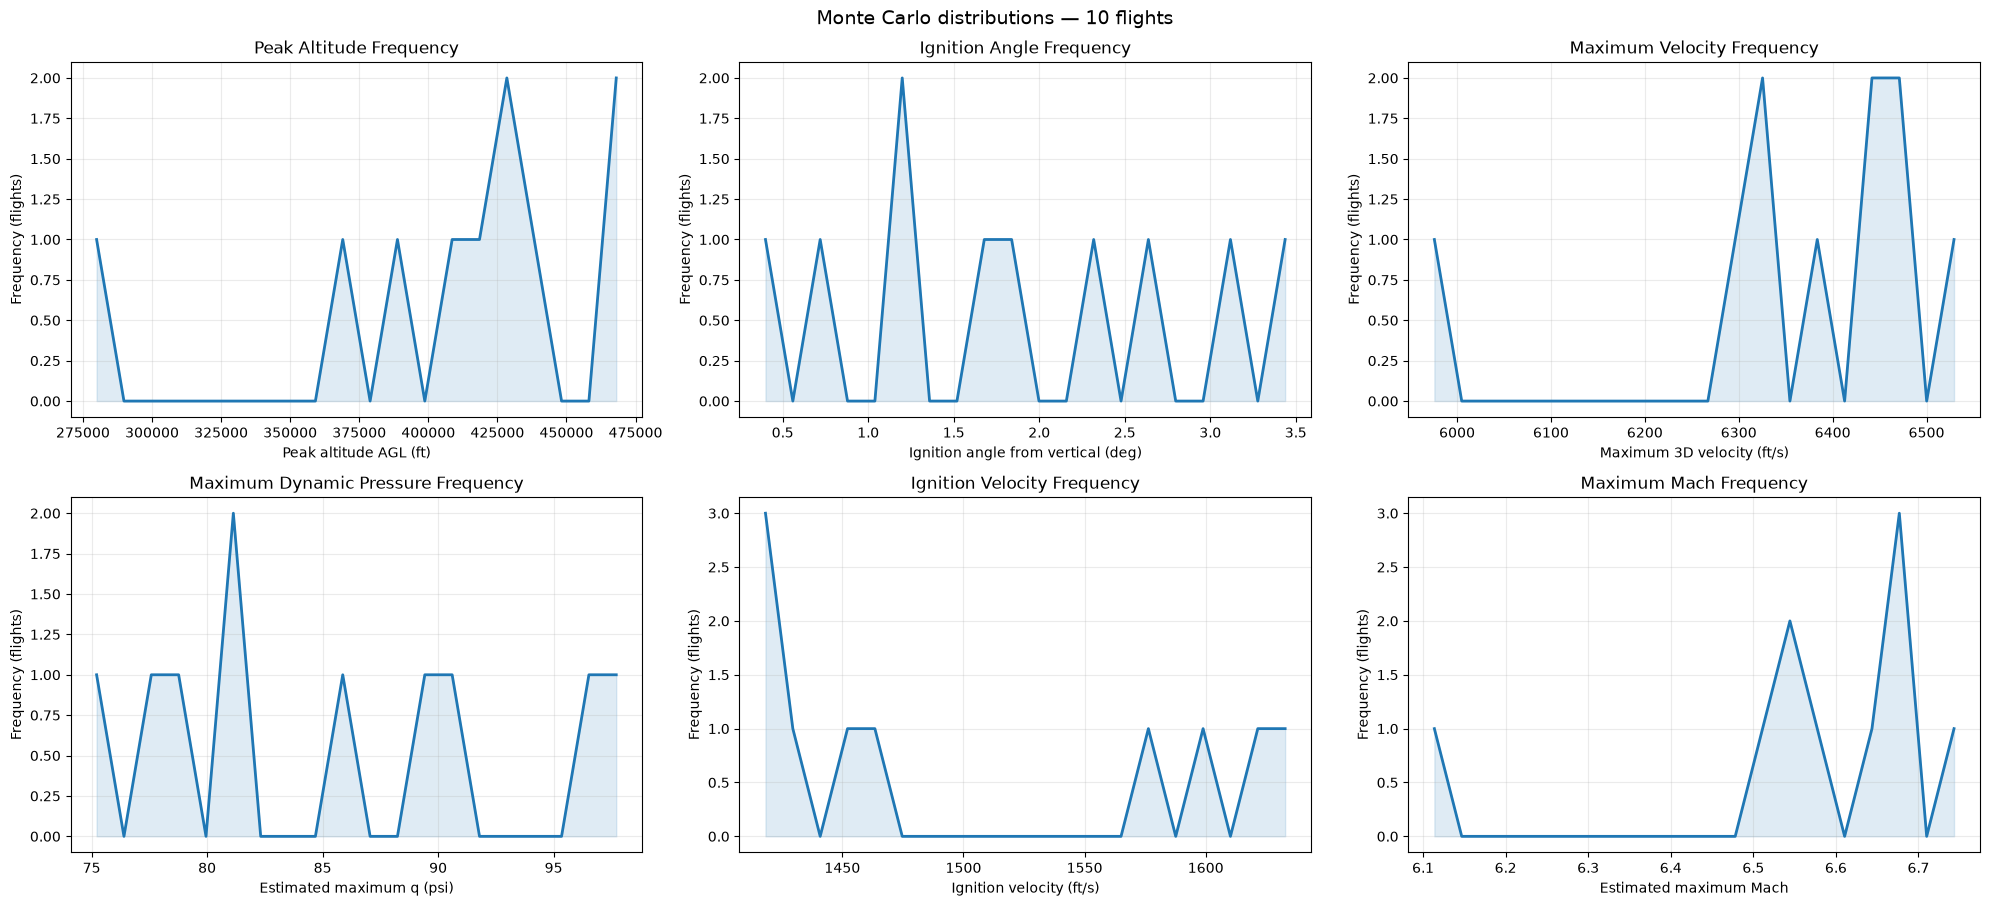

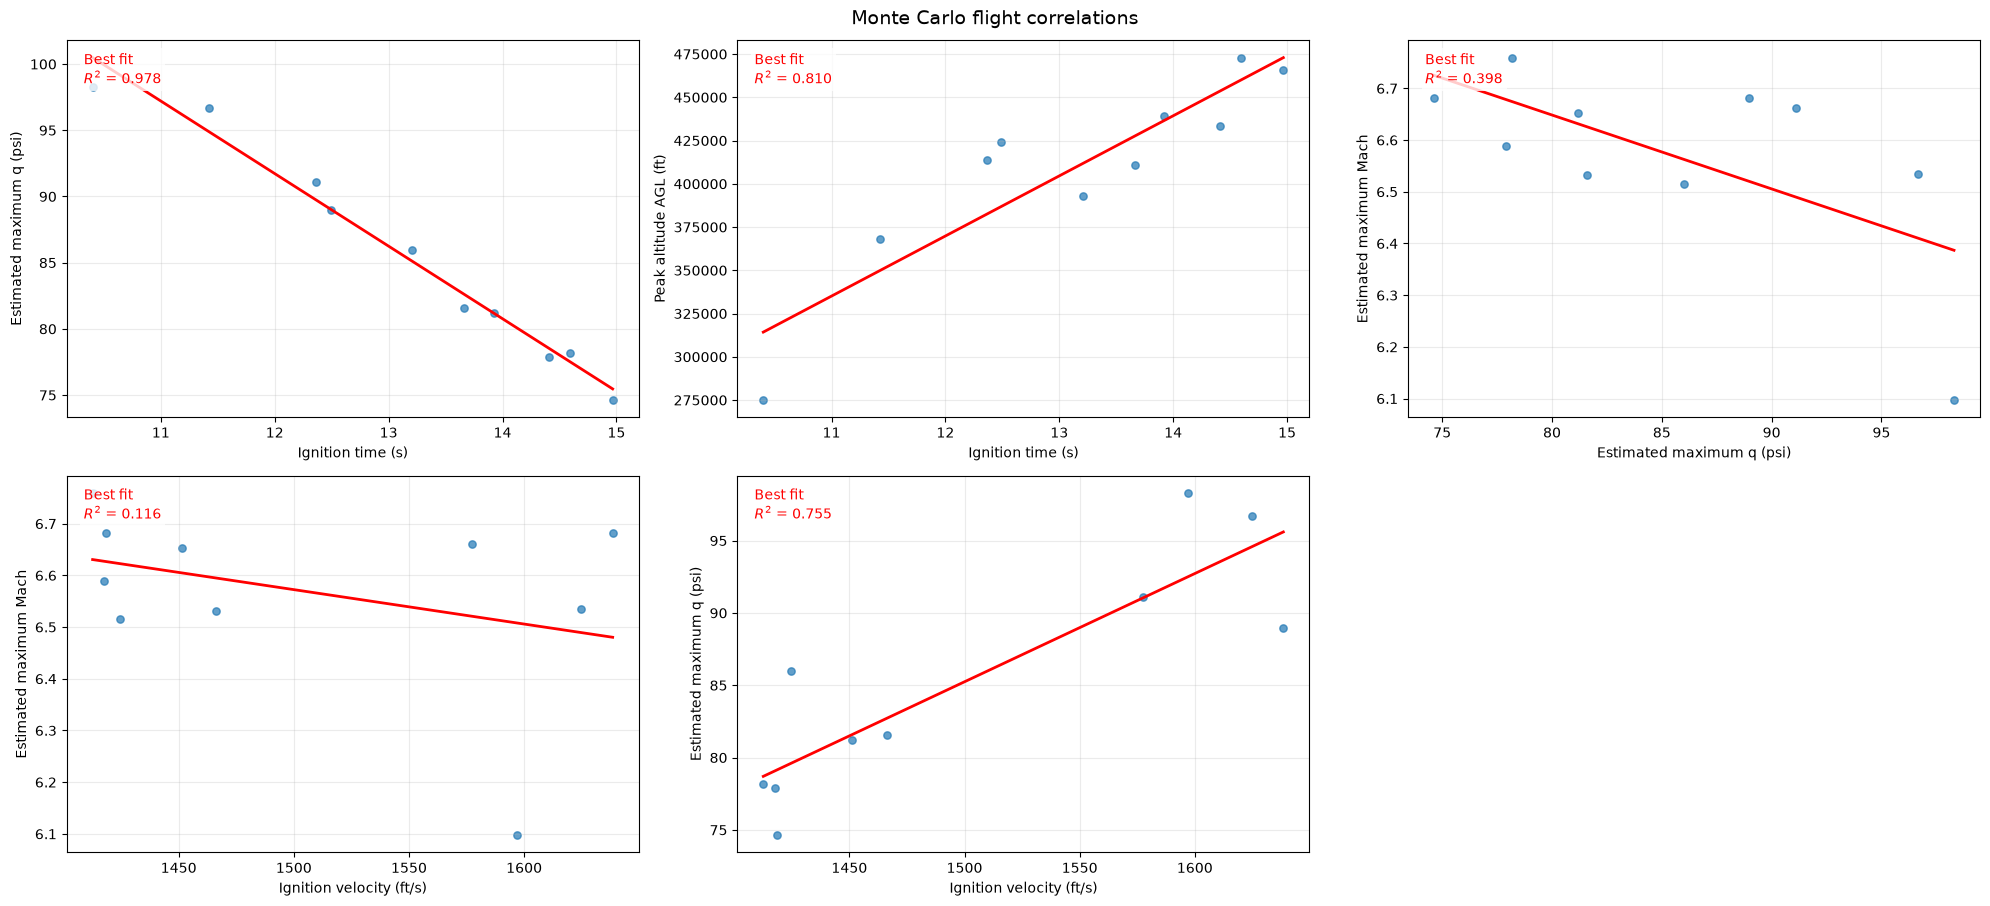

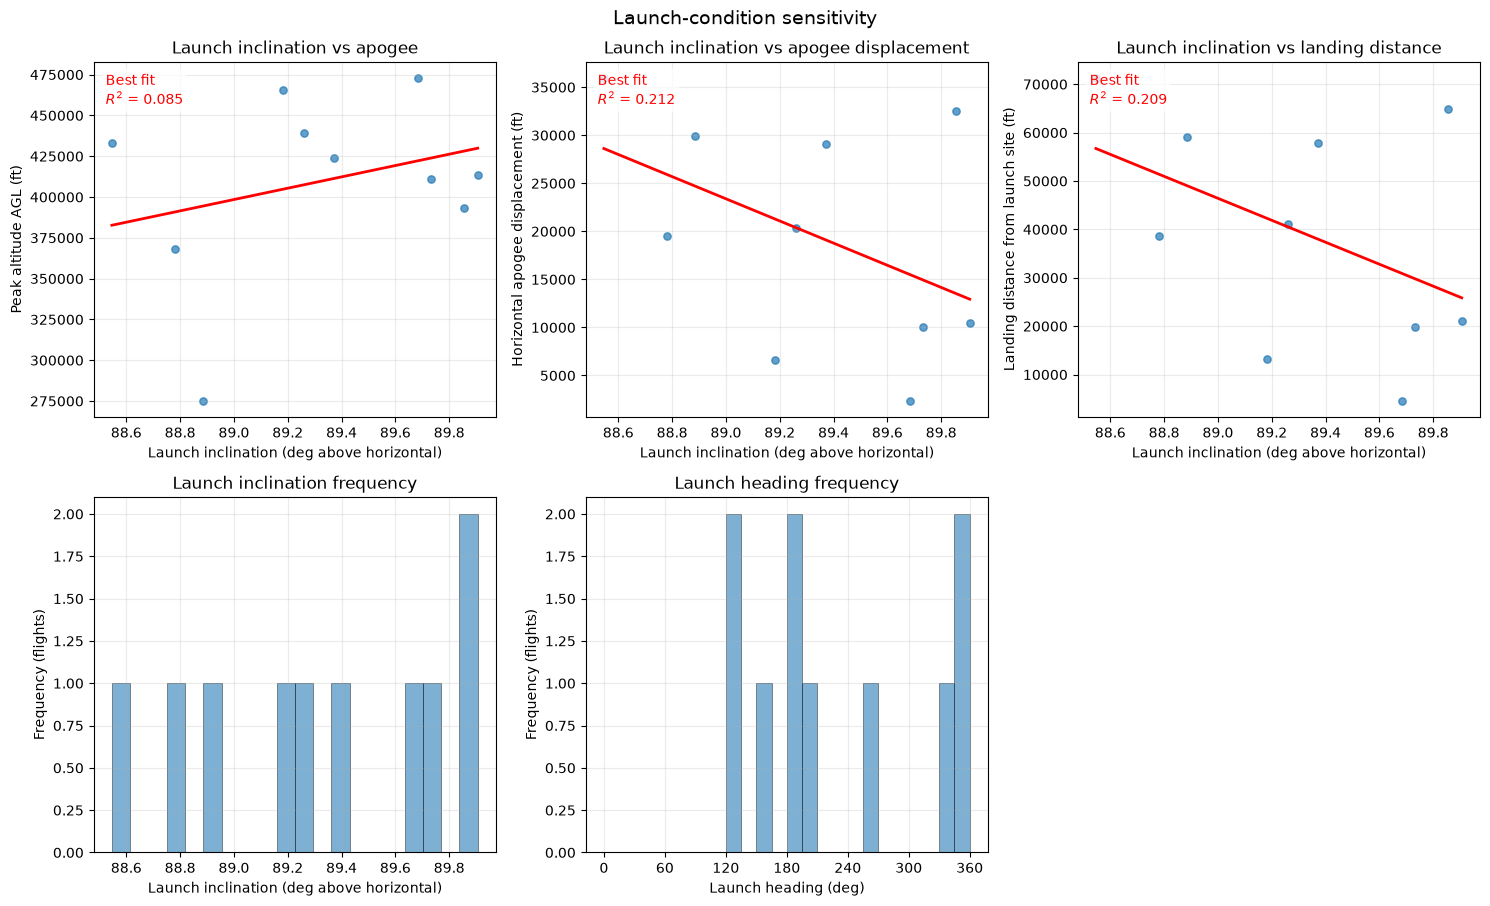

In [179]:

def add_linear_best_fit(axis, x_values, y_values):
    """Add a least-squares line and its coefficient of determination to an axis."""
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    finite = np.isfinite(x_values) & np.isfinite(y_values)
    x_values = x_values[finite]
    y_values = y_values[finite]
    if len(x_values) < 2 or np.unique(x_values).size < 2:
        return None

    slope, intercept = np.polyfit(x_values, y_values, 1)
    predicted = slope * x_values + intercept
    residual_sum_squares = np.sum((y_values - predicted) ** 2)
    total_sum_squares = np.sum((y_values - np.mean(y_values)) ** 2)
    r_squared = (
        1.0 - residual_sum_squares / total_sum_squares
        if total_sum_squares > np.finfo(float).eps
        else np.nan
    )
    r_squared_label = f"{r_squared:.3f}" if np.isfinite(r_squared) else "N/A"
    x_fit = np.linspace(np.min(x_values), np.max(x_values), 100)
    axis.plot(x_fit, slope * x_fit + intercept, color="red", linewidth=2)
    axis.text(
        0.03, 0.97, f"Best fit\n$R^2$ = {r_squared_label}",
        transform=axis.transAxes, ha="left", va="top", color="red",
        bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none", "pad": 2.5},
    )
    return r_squared

plot_definitions = [
    ("peak_altitude_ft_agl", "Peak altitude AGL (ft)", "Peak Altitude Frequency"),
    ("ignition_angle_deg_from_vertical", "Ignition angle from vertical (deg)", "Ignition Angle Frequency"),
    ("max_velocity_ft_s", "Maximum 3D velocity (ft/s)", "Maximum Velocity Frequency"),
    ("max_dynamic_pressure_psi_estimated", "Estimated maximum q (psi)", "Maximum Dynamic Pressure Frequency"),
    ("ignition_velocity_ft_s", "Ignition velocity (ft/s)", "Ignition Velocity Frequency"),
    ("max_mach_estimated", "Estimated maximum Mach", "Maximum Mach Frequency"),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 9.2))
axes = axes.ravel()
rocket_groups = list(plot_flight_metrics.groupby("rocket_name", sort=False))

for axis, (metric, x_label, title) in zip(axes, plot_definitions):
    all_values = plot_flight_metrics[metric].dropna().to_numpy()
    if all_values.size == 0:
        axis.text(0.5, 0.5, "No valid data", ha="center", va="center")
        continue
    shared_bins = np.histogram_bin_edges(all_values, bins=HISTOGRAM_BINS)
    bin_centers = 0.5 * (shared_bins[:-1] + shared_bins[1:])
    for rocket_name, group in rocket_groups:
        counts, _ = np.histogram(group[metric].dropna(), bins=shared_bins)
        frequency_line, = axis.plot(
            bin_centers, counts, linewidth=2, label=rocket_name,
        )
        axis.fill_between(
            bin_centers, counts, 0, color=frequency_line.get_color(), alpha=0.14,
        )
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel("Frequency (flights)")
    axis.grid(alpha=0.25)
    if len(rocket_groups) > 1:
        axis.legend()

fig.suptitle(f"Monte Carlo distributions — {len(plot_flight_metrics):,} flights", fontsize=14)
fig.tight_layout()
REPORT_FIGURES.append(fig)
plt.show()

correlation_plots = [
    ("ignition_time_s", "max_dynamic_pressure_psi_estimated", "Ignition time (s)", "Estimated maximum q (psi)"),
    ("ignition_time_s", "peak_altitude_ft_agl", "Ignition time (s)", "Peak altitude AGL (ft)"),
    ("max_dynamic_pressure_psi_estimated", "max_mach_estimated", "Estimated maximum q (psi)", "Estimated maximum Mach"),
    ("ignition_velocity_ft_s", "max_mach_estimated", "Ignition velocity (ft/s)", "Estimated maximum Mach"),
    ("ignition_velocity_ft_s", "max_dynamic_pressure_psi_estimated", "Ignition velocity (ft/s)", "Estimated maximum q (psi)"),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 9.2))
axes = axes.ravel()
for axis, (x_metric, y_metric, x_label, y_label) in zip(axes, correlation_plots):
    for rocket_name, group in rocket_groups:
        valid = group[[x_metric, y_metric]].dropna()
        if valid.empty:
            continue
        axis.scatter(valid[x_metric], valid[y_metric], alpha=0.7, s=28, label=rocket_name)
    combined_valid = plot_flight_metrics[[x_metric, y_metric]].dropna()
    add_linear_best_fit(axis, combined_valid[x_metric], combined_valid[y_metric])
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.grid(alpha=0.25)
    if len(rocket_groups) > 1:
        axis.legend()
for axis in axes[len(correlation_plots):]:
    axis.remove()
fig.suptitle("Monte Carlo flight correlations", fontsize=14)
fig.tight_layout()
REPORT_FIGURES.append(fig)
plt.show()

launch_plot_specs = [
    ("peak_altitude_ft_agl", "Peak altitude AGL (ft)", "Launch inclination vs apogee"),
    ("apogee_horizontal_distance_ft", "Horizontal apogee displacement (ft)", "Launch inclination vs apogee displacement"),
    ("landing_distance_ft", "Landing distance from launch site (ft)", "Launch inclination vs landing distance"),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 9.2))
axes = axes.ravel()
for axis, (y_metric, y_label, title) in zip(axes, launch_plot_specs):
    for rocket_name, group in rocket_groups:
        valid = group[["launch_inclination_deg", y_metric]].dropna()
        if not valid.empty:
            axis.scatter(valid["launch_inclination_deg"], valid[y_metric], alpha=0.7, s=28, label=rocket_name)
    combined_valid = plot_flight_metrics[["launch_inclination_deg", y_metric]].dropna()
    add_linear_best_fit(axis, combined_valid["launch_inclination_deg"], combined_valid[y_metric])
    axis.set_title(title)
    axis.set_xlabel("Launch inclination (deg above horizontal)")
    axis.set_ylabel(y_label)
    axis.grid(alpha=0.25)
    if len(rocket_groups) > 1:
        axis.legend()

inclination_axis = axes[3]
inclination_values = plot_flight_metrics["launch_inclination_deg"].dropna().to_numpy()
if inclination_values.size:
    inclination_bins = np.histogram_bin_edges(inclination_values, bins=HISTOGRAM_BINS)
    for rocket_name, group in rocket_groups:
        inclination_axis.hist(group["launch_inclination_deg"].dropna(), bins=inclination_bins, alpha=0.58, edgecolor="black", linewidth=0.5, label=rocket_name)
else:
    inclination_axis.text(0.5, 0.5, "No valid data", ha="center", va="center")
inclination_axis.set_title("Launch inclination frequency")
inclination_axis.set_xlabel("Launch inclination (deg above horizontal)")
inclination_axis.set_ylabel("Frequency (flights)")
inclination_axis.grid(alpha=0.25)

heading_axis = axes[4]
heading_bins = np.linspace(0.0, 360.0, 25)
for rocket_name, group in rocket_groups:
    heading_axis.hist(group["launch_heading_deg"].dropna() % 360.0, bins=heading_bins, alpha=0.58, edgecolor="black", linewidth=0.5, label=rocket_name)
heading_axis.set_title("Launch heading frequency")
heading_axis.set_xlabel("Launch heading (deg)")
heading_axis.set_ylabel("Frequency (flights)")
heading_axis.set_xticks(np.arange(0, 361, 60))
heading_axis.grid(alpha=0.25)
if len(rocket_groups) > 1:
    inclination_axis.legend()
    heading_axis.legend()
axes[5].remove()
fig.suptitle("Launch-condition sensitivity", fontsize=14)
fig.tight_layout()
REPORT_FIGURES.append(fig)
plt.show()

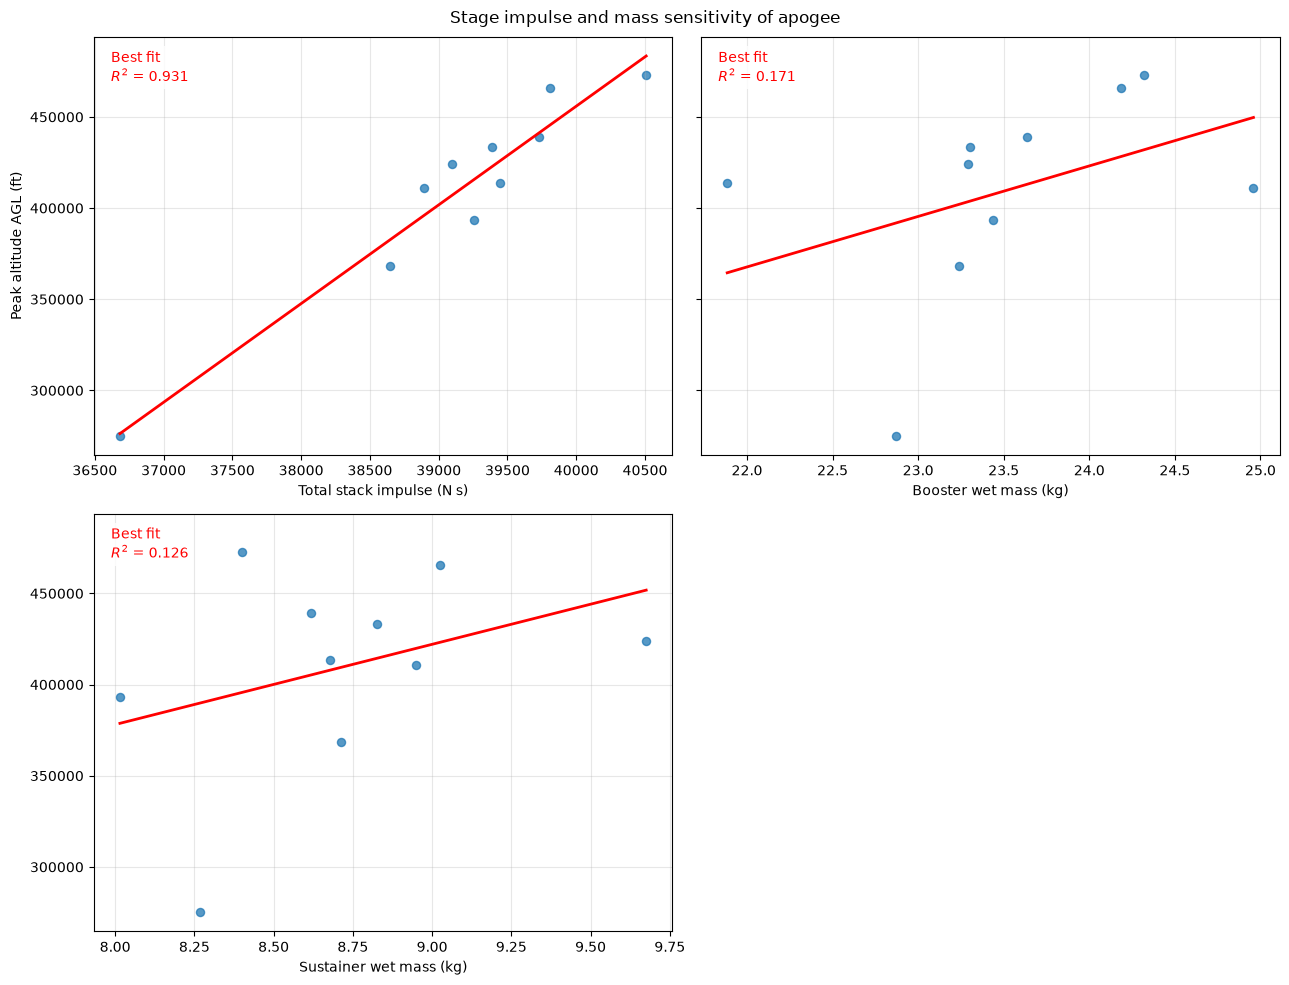

Impulse audit passed: booster + sustainer equals the requested scaled total for every recorded flight.


,booster_impulse_n_s,sustainer_impulse_n_s,nominal_total_impulse_n_s,sustainer_booster_impulse_ratio_percent,summed_realized_impulse_n_s,added_impulse_n_s,requested_total_impulse_n_s,scaling_error_n_s
count,10.000,10.000,10.000,10.000,10.000,10.000,10.000,10.0
mean,28596.834,10548.435,38711.081,101.122,39145.269,434.188,39145.269,-0.0
std,737.996,272.223,0.000,2.610,1010.219,1010.219,1010.219,0.0
min,26797.824,9884.839,38711.081,94.760,36682.663,-2028.418,36682.663,-0.0
25%,28448.790,10493.826,38711.081,100.598,38942.616,231.535,38942.616,-0.0
50%,28725.161,10595.770,38711.081,101.575,39320.931,609.850,39320.931,0.0
75%,28970.538,10686.282,38711.081,102.443,39656.819,945.738,39656.819,0.0
max,29592.619,10915.747,38711.081,104.643,40508.366,1797.285,40508.366,0.0


Observed low/high stage bounds across this Monte Carlo sweep:


,Low (SI),High (SI),SI unit,Low (imperial),High (imperial),Imperial unit
Quantity,,,,,,
Booster impulse,26797.824,29592.619,N s,6024.390,6652.685,lbf s
Sustainer impulse,9884.839,10915.747,N s,2222.200,2453.958,lbf s
Booster wet mass,21.884,24.959,kg,48.246,55.025,lb
Sustainer wet mass,8.015,9.675,kg,17.670,21.331,lb


In [180]:
sensitivity_parameter_labels = {
    "total_impulse_n_s": "Total stack impulse (N s)",
    "booster_wet_mass_kg": "Booster wet mass (kg)",
    "sustainer_wet_mass_kg": "Sustainer wet mass (kg)",
}
sensitivity_records = []
for record_index, flight in enumerate(plot_flights):
    parameters = flight.get("simulation_parameters", {})
    impulses = flight.get("stage_impulses", {})
    masses = flight.get("stage_masses", {})
    states = np.asarray(flight.get("solution", ()), dtype=float)
    if states.ndim != 2 or states.shape[0] == 0:
        continue
    apogee_ft_agl = (np.nanmax(states[:, column["z"]]) - launch_elevation_m) * 3.28084
    booster_impulse_n_s = float(impulses.get("booster_impulse_n_s", np.nan))
    sustainer_impulse_n_s = float(impulses.get("sustainer_impulse_n_s", np.nan))
    sensitivity_records.append({
        "apogee_ft_agl": float(apogee_ft_agl),
        "sustainer_booster_impulse_ratio_percent": float(parameters.get("sustainer_booster_impulse_ratio_percent", np.nan)),
        "booster_impulse_n_s": booster_impulse_n_s,
        "sustainer_impulse_n_s": sustainer_impulse_n_s,
        "total_impulse_n_s": float(impulses.get("total_impulse_n_s", booster_impulse_n_s + sustainer_impulse_n_s)),
        "nominal_total_impulse_n_s": float(impulses.get("nominal_total_impulse_n_s", np.nan)),
        "booster_wet_mass_kg": float(masses.get("booster_wet_mass_kg", np.nan)),
        "sustainer_wet_mass_kg": float(masses.get("sustainer_wet_mass_kg", np.nan)),
    })

stage_sensitivity = pd.DataFrame.from_records(sensitivity_records)
figure_columns = 2
figure_rows = int(np.ceil(len(sensitivity_parameter_labels) / figure_columns))
fig, axes = plt.subplots(figure_rows, figure_columns, figsize=(13, 5 * figure_rows), sharey=True)
axes = np.atleast_1d(axes).ravel()
for axis, (parameter, label) in zip(axes, sensitivity_parameter_labels.items()):
    valid = stage_sensitivity[[parameter, "apogee_ft_agl"]].dropna()
    if valid.empty:
        axis.text(0.5, 0.5, "No sweep data", ha="center", va="center")
    else:
        axis.scatter(valid[parameter], valid["apogee_ft_agl"], s=34, alpha=0.75)
        add_linear_best_fit(axis, valid[parameter], valid["apogee_ft_agl"])
    axis.set_xlabel(label)
    axis.grid(alpha=0.3)
for axis in axes[len(sensitivity_parameter_labels):]:
    axis.remove()
axes[0].set_ylabel("Peak altitude AGL (ft)")
fig.suptitle("Stage impulse and mass sensitivity of apogee")
fig.tight_layout()
REPORT_FIGURES.append(fig)
plt.show()

impulse_columns = ["booster_impulse_n_s", "sustainer_impulse_n_s", "nominal_total_impulse_n_s", "sustainer_booster_impulse_ratio_percent"]
impulse_audit = stage_sensitivity[impulse_columns].dropna().copy()
if impulse_audit.empty:
    print("Impulse audit unavailable: rerun montecarlorunner.py to store stage_impulses in the pickle.")
else:
    impulse_audit["summed_realized_impulse_n_s"] = (
        impulse_audit["booster_impulse_n_s"] + impulse_audit["sustainer_impulse_n_s"]
    )
    impulse_audit["added_impulse_n_s"] = (
        impulse_audit["summed_realized_impulse_n_s"] - impulse_audit["nominal_total_impulse_n_s"]
    )
    impulse_audit["requested_total_impulse_n_s"] = (
        impulse_audit["nominal_total_impulse_n_s"]
        * impulse_audit["sustainer_booster_impulse_ratio_percent"] / 100.0
    )
    impulse_audit["scaling_error_n_s"] = (
        impulse_audit["summed_realized_impulse_n_s"] - impulse_audit["requested_total_impulse_n_s"]
    )
    if not np.allclose(
        impulse_audit["summed_realized_impulse_n_s"],
        impulse_audit["requested_total_impulse_n_s"],
        rtol=1e-12,
        atol=1e-6,
    ):
        maximum_error = impulse_audit["scaling_error_n_s"].abs().max()
        raise RuntimeError(f"Stage thrust scaling missed its requested total by {maximum_error:.6g} N s")
    print("Impulse audit passed: booster + sustainer equals the requested scaled total for every recorded flight.")

if not impulse_audit.empty:
    display(impulse_audit.describe().round(3))

bound_specs = [
    ("Booster impulse", "booster_impulse_n_s", "N s", 0.224808943, "lbf s"),
    ("Sustainer impulse", "sustainer_impulse_n_s", "N s", 0.224808943, "lbf s"),
    ("Booster wet mass", "booster_wet_mass_kg", "kg", 2.20462262, "lb"),
    ("Sustainer wet mass", "sustainer_wet_mass_kg", "kg", 2.20462262, "lb"),
]
bound_rows = []
for quantity, field, si_unit, conversion, imperial_unit in bound_specs:
    observed = stage_sensitivity[field].dropna()
    if not observed.empty:
        bound_rows.append({
            "Quantity": quantity,
            "Low (SI)": observed.min(),
            "High (SI)": observed.max(),
            "SI unit": si_unit,
            "Low (imperial)": observed.min() * conversion,
            "High (imperial)": observed.max() * conversion,
            "Imperial unit": imperial_unit,
        })

stage_bounds = pd.DataFrame.from_records(bound_rows)
if stage_bounds.empty:
    print("Stage bounds unavailable: regenerate the Monte Carlo pickle with the current runner.")
else:
    print("Observed low/high stage bounds across this Monte Carlo sweep:")
    display(stage_bounds.set_index("Quantity").round(3))
    if len(stage_bounds) < len(bound_specs):
        print("Mass bounds unavailable in this older pickle; regenerate it with the current runner.")

## Export flight paths and landing points to Google Earth

The export converts RocketPy's local east/north coordinates to latitude and longitude around the launch site stored in the pickle. Flight-path altitude is written as absolute altitude above sea level. A landing placemark is added only when RocketPy reports impact or the final state reaches launch elevation.

`KML_MAX_PATH_POINTS` limits the number of coordinates per flight so large Monte Carlo sweeps remain responsive in Google Earth. Set it to `None` to export every state.

In [181]:
import simplekml

KML_OUTPUT_PATH = PROJECT_DIR / "monte_carlo_flights.kml"
KML_MAX_PATH_POINTS = 2_000
KML_LINE_WIDTH = 3
KML_PATH_ALPHA = 140  # 0 is invisible; 255 is opaque
KML_LANDING_LABEL_SCALE = 0.35
KML_INCLUDE_APOGEE_ELLIPSES = False

Saved Google Earth KML: C:\Users\E\Documents\GitHub\farfromheaven\sims\rocketpy\monte_carlo_flights.kml


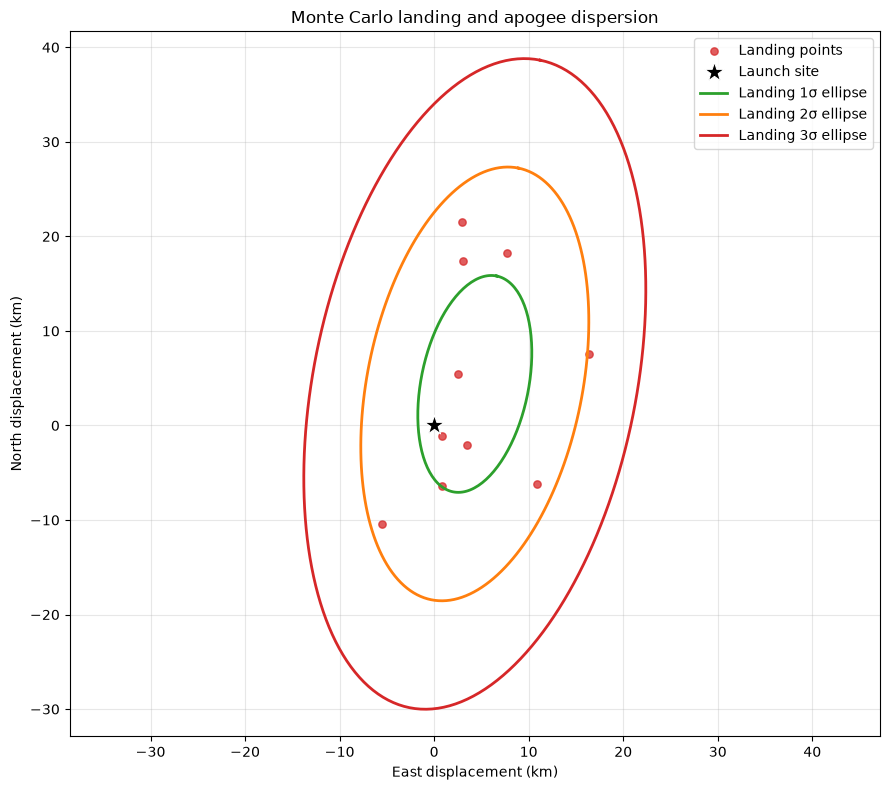

,simulation,rocket_name,states_in_pickle,path_points_exported,landing_exported
0,1,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,6360,2000,True
1,2,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,6419,2000,True
2,3,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,6283,2000,True
3,4,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,6440,2000,True
4,5,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,6621,2000,True
5,6,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,6362,2000,True
6,7,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,6374,2000,True
7,8,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,6142,2000,True
8,9,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,6679,2000,True
9,10,AMA CONFIG 14 - Full Stack -> AMA CONFIG 14 - ...,6606,2000,True


In [182]:


EARTH_RADIUS_M = 6_378_137.0
environment_metadata = monte_carlo.get("environment", {})
origin_latitude = environment_metadata.get("latitude")
origin_longitude = environment_metadata.get("longitude")
origin_elevation_m = float(environment_metadata.get("elevation") or 0.0)
if origin_latitude is None or origin_longitude is None:
    raise ValueError("The pickle does not contain launch latitude and longitude")
origin_latitude = float(origin_latitude)
origin_longitude = float(origin_longitude)
longitude_scale = EARTH_RADIUS_M * np.cos(np.radians(origin_latitude))
if abs(longitude_scale) < 1e-9:
    raise ValueError("Cannot convert local coordinates at a geographic pole")

def local_xy_to_lon_lat(x_east_m, y_north_m):
    latitude = origin_latitude + np.degrees(float(y_north_m) / EARTH_RADIUS_M)
    longitude = origin_longitude + np.degrees(float(x_east_m) / longitude_scale)
    return longitude, latitude

def path_indices(state_count, maximum_points):
    if maximum_points is None or state_count <= maximum_points:
        return np.arange(state_count, dtype=int)
    return np.unique(np.linspace(0, state_count - 1, maximum_points, dtype=int))

def covariance_ellipse(points, standard_deviations=3.0, point_count=181):
    """Return the center, semi-axis lengths, and boundary of a 2-D covariance ellipse."""
    points = np.asarray(points, dtype=float)
    if points.size == 0:
        return None
    if points.ndim == 1:
        if points.size != 2:
            return None
        points = points.reshape(1, 2)
    if points.ndim != 2 or points.shape[1] != 2:
        return None
    points = points[np.all(np.isfinite(points), axis=1)]
    if len(points) < 2:
        return None
    center = points.mean(axis=0)
    eigenvalues, eigenvectors = np.linalg.eigh(np.cov(points, rowvar=False))
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = np.maximum(eigenvalues[order], 0.0)
    eigenvectors = eigenvectors[:, order]
    semi_axes = standard_deviations * np.sqrt(eigenvalues)
    angles = np.linspace(0.0, 2.0 * np.pi, point_count)
    unit_circle = np.vstack((np.cos(angles), np.sin(angles)))
    boundary = center[:, None] + eigenvectors @ (semi_axes[:, None] * unit_circle)
    return center, semi_axes, boundary.T

kml = simplekml.Kml(name="Project Blaze Monte Carlo Flights")
paths_folder = kml.newfolder(name="Flight Paths")
landings_folder = kml.newfolder(name="Landing Points")
statistics_folder = kml.newfolder(name="Statistical Envelopes")

launch_point = kml.newpoint(
    name="Launch Site",
    coords=[(origin_longitude, origin_latitude, origin_elevation_m)],
)
launch_point.altitudemode = simplekml.AltitudeMode.absolute
launch_point.style.iconstyle.icon.href = "https://maps.google.com/mapfiles/kml/shapes/star.png"
launch_point.style.iconstyle.scale = 1.2

path_colors = [
    simplekml.Color.red,
    simplekml.Color.blue,
    simplekml.Color.green,
    simplekml.Color.orange,
    simplekml.Color.purple,
    simplekml.Color.cyan,
]
export_records = []
landing_points_xy = []
apogee_points_xyz = []
landing_color = simplekml.Color.red

for record_index, flight in enumerate(plot_flights):
    states = np.asarray(flight.get("solution", ()), dtype=float)
    if states.ndim != 2 or states.shape[0] == 0:
        continue

    simulation_number = int(flight.get("simulation_index", record_index)) + 1
    rocket_name = flight.get("rocket_name") or f"rocket_{flight.get('rocket_index', 0)}"
    feature_name = f"Run {simulation_number}"
    color = path_colors[record_index % len(path_colors)]
    indices = path_indices(len(states), KML_MAX_PATH_POINTS)
    coordinates = []
    for state in states[indices]:
        longitude, latitude = local_xy_to_lon_lat(state[column["x"]], state[column["y"]])
        coordinates.append((longitude, latitude, float(state[column["z"]])))
    apogee_index = int(np.nanargmax(states[:, column["z"]]))
    apogee_points_xyz.append([
        float(states[apogee_index, column["x"]]),
        float(states[apogee_index, column["y"]]),
        float(states[apogee_index, column["z"]]),
    ])

    path = paths_folder.newlinestring(name=feature_name, coords=coordinates)
    path.altitudemode = simplekml.AltitudeMode.absolute
    path.tessellate = 1
    path.style.linestyle.color = simplekml.Color.changealphaint(KML_PATH_ALPHA, color)
    path.style.linestyle.width = KML_LINE_WIDTH
    path.description = (
        f"States exported: {len(indices):,} of {len(states):,}\n"
        f"Launch inclination: {float(flight.get('launch_angle', np.nan)):.3f} deg"
    )

    events = flight.get("events", {})
    impact_time = events.get("impact_time")
    impact_x = events.get("x_impact")
    impact_y = events.get("y_impact")
    impact_detected = impact_time is not None and impact_x is not None and impact_y is not None
    if not impact_detected and states[-1, column["z"]] <= origin_elevation_m + 1.0:
        impact_detected = True
        impact_time = float(states[-1, column["time"]])
        impact_x = float(states[-1, column["x"]])
        impact_y = float(states[-1, column["y"]])

    if impact_detected:
        landing_points_xy.append([float(impact_x), float(impact_y)])
        landing_longitude, landing_latitude = local_xy_to_lon_lat(impact_x, impact_y)
        landing = landings_folder.newpoint(
            name=f"Landing — {feature_name}",
            coords=[(landing_longitude, landing_latitude, origin_elevation_m)],
        )
        landing.altitudemode = simplekml.AltitudeMode.clamptoground
        landing.style.iconstyle.color = landing_color
        landing.style.iconstyle.scale = 0.2
        landing.style.labelstyle.scale = KML_LANDING_LABEL_SCALE
        landing.style.iconstyle.icon.href = "https://maps.google.com/mapfiles/kml/shapes/placemark_circle.png"
        landing.description = (
            f"Impact time: {float(impact_time):.2f} s\n"
            f"East offset: {float(impact_x):.1f} m\n"
            f"North offset: {float(impact_y):.1f} m"
        )

    export_records.append({
        "simulation": simulation_number,
        "rocket_name": rocket_name,
        "states_in_pickle": len(states),
        "path_points_exported": len(indices),
        "landing_exported": bool(impact_detected),
    })

sigma_levels = (1.0, 2.0, 3.0)
landing_ellipses = {
    sigma: covariance_ellipse(landing_points_xy, standard_deviations=sigma)
    for sigma in sigma_levels
}
apogee_points_xyz = np.asarray(apogee_points_xyz, dtype=float)
apogee_ellipses = {
    sigma: covariance_ellipse(apogee_points_xyz[:, :2], standard_deviations=sigma)
    if len(apogee_points_xyz) else None
    for sigma in sigma_levels
}

def add_kml_ellipse(name, ellipse, altitude_m, color, sigma, clamp_to_ground=False):
    if ellipse is None:
        return
    center, semi_axes, boundary = ellipse
    coordinate_altitude = 0.0 if clamp_to_ground else float(altitude_m)
    coordinates = [(*local_xy_to_lon_lat(x, y), coordinate_altitude) for x, y in boundary]
    feature = statistics_folder.newlinestring(name=name, coords=coordinates)
    feature.tessellate = 1
    feature.altitudemode = (
        simplekml.AltitudeMode.clamptoground
        if clamp_to_ground
        else simplekml.AltitudeMode.absolute
    )
    feature.style.linestyle.color = color
    feature.style.linestyle.width = 5
    feature.description = (
        f"Center: {center[0]:.1f} m east, {center[1]:.1f} m north\n"
        f"{sigma:g}-sigma semi-axes: {semi_axes[0]:.1f} m, {semi_axes[1]:.1f} m"
    )

landing_sigma_colors = {1.0: simplekml.Color.orange, 2.0: simplekml.Color.yellow, 3.0: simplekml.Color.red}
apogee_sigma_colors = {1.0: simplekml.Color.cyan, 2.0: simplekml.Color.blue, 3.0: simplekml.Color.purple}
for sigma in sigma_levels:
    add_kml_ellipse(
        f"Landing {sigma:g}-sigma ellipse", landing_ellipses[sigma],
        0.0, landing_sigma_colors[sigma], sigma, clamp_to_ground=True,
    )
    if KML_INCLUDE_APOGEE_ELLIPSES:
        add_kml_ellipse(
            f"Apogee {sigma:g}-sigma ellipse", apogee_ellipses[sigma],
            float(np.mean(apogee_points_xyz[:, 2])) if len(apogee_points_xyz) else origin_elevation_m,
            apogee_sigma_colors[sigma], sigma,
        )

KML_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
kml.save(str(KML_OUTPUT_PATH))
print(f"Saved Google Earth KML: {KML_OUTPUT_PATH}")

fig, axis = plt.subplots(figsize=(9, 8))
landing_points_xy = np.asarray(landing_points_xy, dtype=float)
if len(landing_points_xy):
    landing_east_km = landing_points_xy[:, 0] / 1000
    landing_north_km = landing_points_xy[:, 1] / 1000
    axis.scatter(landing_east_km, landing_north_km, color="tab:red", s=28, alpha=0.75, label="Landing points")
axis.scatter(0.0, 0.0, marker="*", color="black", edgecolor="white", s=220, linewidth=0.8, label="Launch site", zorder=5)
plot_sigma_colors = {1.0: "tab:green", 2.0: "tab:orange", 3.0: "tab:red"}
for sigma in sigma_levels:
    landing_ellipse = landing_ellipses[sigma]
    if landing_ellipse is not None:
        boundary = landing_ellipse[2]
        axis.plot(boundary[:, 0] / 1000, boundary[:, 1] / 1000, color=plot_sigma_colors[sigma], linewidth=2, label=f"Landing {sigma:g}σ ellipse")
    apogee_ellipse = apogee_ellipses[sigma]
    if KML_INCLUDE_APOGEE_ELLIPSES and apogee_ellipse is not None:
        boundary = apogee_ellipse[2]
        axis.plot(boundary[:, 0] / 1000, boundary[:, 1] / 1000, color=plot_sigma_colors[sigma], linestyle="--", linewidth=1.8, label=f"Apogee {sigma:g}σ ellipse")
axis.set_title("Monte Carlo landing and apogee dispersion")
axis.set_xlabel("East displacement (km)")
axis.set_ylabel("North displacement (km)")
axis.set_aspect("equal", adjustable="datalim")
axis.grid(alpha=0.3)
axis.legend()
fig.tight_layout()
REPORT_FIGURES.append(fig)
plt.show()

pd.DataFrame.from_records(export_records)

In [183]:
from io import BytesIO
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image

report_figures = list(dict.fromkeys(REPORT_FIGURES))
if not report_figures:
    raise ValueError("No report figures are available; run the graph cells first")

REPORT_OUTPUT_PATH = Path(REPORT_OUTPUT_PATH).expanduser().resolve()
REPORT_PNG_OUTPUT_PATH = Path(REPORT_PNG_OUTPUT_PATH).expanduser().resolve()
REPORT_PNG_DPI = int(REPORT_PNG_DPI)
if REPORT_OUTPUT_PATH.suffix.lower() != ".pdf":
    raise ValueError("REPORT_OUTPUT_PATH must end in .pdf")
if REPORT_PNG_OUTPUT_PATH.suffix.lower() != ".png":
    raise ValueError("REPORT_PNG_OUTPUT_PATH must end in .png")
if REPORT_PNG_DPI <= 0:
    raise ValueError("REPORT_PNG_DPI must be positive")
REPORT_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_PNG_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

with PdfPages(
    REPORT_OUTPUT_PATH,
    metadata={"Title": "Project Blaze Monte Carlo Flight Report"},
) as report_pdf:
    for report_figure in report_figures:
        report_pdf.savefig(report_figure, bbox_inches="tight", facecolor="white")

rendered_figures = []
for report_figure in report_figures:
    image_buffer = BytesIO()
    report_figure.savefig(
        image_buffer, format="png", dpi=REPORT_PNG_DPI,
        bbox_inches="tight", facecolor="white",
    )
    image_buffer.seek(0)
    with Image.open(image_buffer) as rendered_image:
        rendered_figures.append(rendered_image.convert("RGB").copy())
    image_buffer.close()

separator_height = max(1, REPORT_PNG_DPI // 5)
report_width = max(image.width for image in rendered_figures)
report_height = (
    sum(image.height for image in rendered_figures)
    + separator_height * (len(rendered_figures) - 1)
)
combined_report = Image.new("RGB", (report_width, report_height), "white")
top = 0
for image in rendered_figures:
    left = (report_width - image.width) // 2
    combined_report.paste(image, (left, top))
    top += image.height + separator_height
combined_report.save(
    REPORT_PNG_OUTPUT_PATH, format="PNG",
    dpi=(REPORT_PNG_DPI, REPORT_PNG_DPI), optimize=True,
)
for image in rendered_figures:
    image.close()
combined_report.close()

print(f"Saved {len(report_figures)} figures to PDF: {REPORT_OUTPUT_PATH}")
print(f"Saved combined {REPORT_PNG_DPI}-DPI PNG: {REPORT_PNG_OUTPUT_PATH}")

Saved 5 figures to PDF: C:\Users\E\Documents\GitHub\farfromheaven\sims\rocketpy\monte_carlo_report.pdf
Saved combined 300-DPI PNG: C:\Users\E\Documents\GitHub\farfromheaven\sims\rocketpy\monte_carlo_report.png


In [184]:
profile_columns = ("time", "x", "y", "z", "vx", "vy", "vz", "e0", "e1", "e2", "e3")
profile_percentile = float(FLIGHT_PROFILE_PERCENTILE)
profile_time_step_s = float(FLIGHT_PROFILE_TIME_STEP_S)
if not np.isfinite(profile_percentile) or not 0 <= profile_percentile <= 100:
    raise ValueError("FLIGHT_PROFILE_PERCENTILE must be in [0, 100]")
if not np.isfinite(profile_time_step_s) or profile_time_step_s <= 0:
    raise ValueError("FLIGHT_PROFILE_TIME_STEP_S must be positive")
missing_profile_columns = set(profile_columns).difference(state_columns)
if missing_profile_columns:
    raise ValueError(f"Flight data is missing profile columns: {sorted(missing_profile_columns)}")

profile_column_indices = [column[name] for name in profile_columns]
profile_histories = []
for record_index, flight in enumerate(plot_flights):
    states = np.asarray(flight.get("solution", ()), dtype=float)
    if states.ndim != 2 or states.shape[0] < 2 or states.shape[1] < len(state_columns):
        continue
    states = states[:, profile_column_indices]
    finite_time = np.isfinite(states[:, 0])
    states = states[finite_time]
    _, unique_indices = np.unique(states[:, 0], return_index=True)
    states = states[np.sort(unique_indices)]
    if len(states) < 2 or np.any(np.diff(states[:, 0]) <= 0):
        continue

    # RocketPy quaternions q and -q represent the same attitude. Align
    # their signs through time before percentile interpolation.
    quaternion = states[:, 7:11].copy()
    for state_index in range(1, len(quaternion)):
        if np.dot(quaternion[state_index - 1], quaternion[state_index]) < 0:
            quaternion[state_index] *= -1
    if quaternion[0, 0] < 0:
        quaternion *= -1
    states[:, 7:11] = quaternion
    profile_histories.append(states)

if not profile_histories:
    raise ValueError("No valid flights remain for percentile profile generation")

profile_start_time = min(states[0, 0] for states in profile_histories)
profile_end_time = max(states[-1, 0] for states in profile_histories)
profile_time = np.arange(
    profile_start_time, profile_end_time + profile_time_step_s * 0.5, profile_time_step_s
)
profile_time = profile_time[profile_time <= profile_end_time]
if profile_time[-1] < profile_end_time:
    profile_time = np.append(profile_time, profile_end_time)

profile_data = {"time": profile_time}
for profile_column_offset, profile_column_name in enumerate(profile_columns[1:], start=1):
    interpolated_values = np.full((len(profile_histories), len(profile_time)), np.nan)
    for flight_index, states in enumerate(profile_histories):
        interpolated_values[flight_index] = np.interp(
            profile_time,
            states[:, 0],
            states[:, profile_column_offset],
            left=np.nan,
            right=np.nan,
        )
    profile_data[profile_column_name] = np.nanpercentile(
        interpolated_values, profile_percentile, axis=0
    )

profile_frame = pd.DataFrame(profile_data, columns=profile_columns)
profile_quaternion = profile_frame[["e0", "e1", "e2", "e3"]].to_numpy(copy=True)
quaternion_norm = np.linalg.norm(profile_quaternion, axis=1)
valid_quaternion = np.isfinite(quaternion_norm) & (quaternion_norm > 0)
profile_quaternion[valid_quaternion] /= quaternion_norm[valid_quaternion, None]
profile_quaternion[~valid_quaternion] = (1.0, 0.0, 0.0, 0.0)
profile_frame.loc[:, ["e0", "e1", "e2", "e3"]] = profile_quaternion

AVERAGE_FLIGHT_PROFILE_PATH = Path(AVERAGE_FLIGHT_PROFILE_PATH).expanduser().resolve()
AVERAGE_FLIGHT_PROFILE_PATH.parent.mkdir(parents=True, exist_ok=True)
profile_frame.to_csv(AVERAGE_FLIGHT_PROFILE_PATH, index=False)
print(
    f"Saved {profile_percentile:g}th-percentile flight profile from "
    f"{len(profile_histories):,} flights and {len(profile_frame):,} time samples to "
    f"{AVERAGE_FLIGHT_PROFILE_PATH}"
)
profile_frame.head()

Saved 80th-percentile flight profile from 10 flights and 3,751 time samples to C:\Users\E\Documents\GitHub\farfromheaven\sims\rocketpy\average_flight_profile_80th_percentile.csv


,time,x,y,z,vx,vy,vz,e0,e1,e2,e3
0,0.0,0.000000,0.000000,1191.000000,0.000000,0.000000,0.000000,0.707948,-0.000320,0.00083,0.706264
1,0.1,0.000903,0.001984,1191.681486,0.016013,0.035034,12.113791,0.707948,-0.000320,0.00083,0.706264
2,0.2,0.003390,0.007415,1193.545662,0.033956,0.074284,25.724106,0.707948,-0.000320,0.00083,0.706264
3,0.3,0.007591,0.016618,1196.762081,0.053052,0.116071,40.224079,0.707948,-0.000320,0.00083,0.706264
4,0.4,0.013865,0.030429,1201.541840,0.074048,0.162462,55.747046,0.707946,-0.000273,0.00085,0.706266
